In [1]:
import pandas as pd
import requests
import torch
from dataclasses import asdict
from datasets import load_dataset
from peft import PeftModel, PeftConfig, AutoPeftModelForCausalLM, get_model_status, \
get_layer_status, prepare_model_for_kbit_training, LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig

In [2]:
from peft import get_model_status, get_layer_status


## Deploying in a Nutshell

Most people do not have GPUs in their
computers, and end-users won’t have Python, PyTorch, and Hugging Face installed either.

### one such example is open neural network exchange 

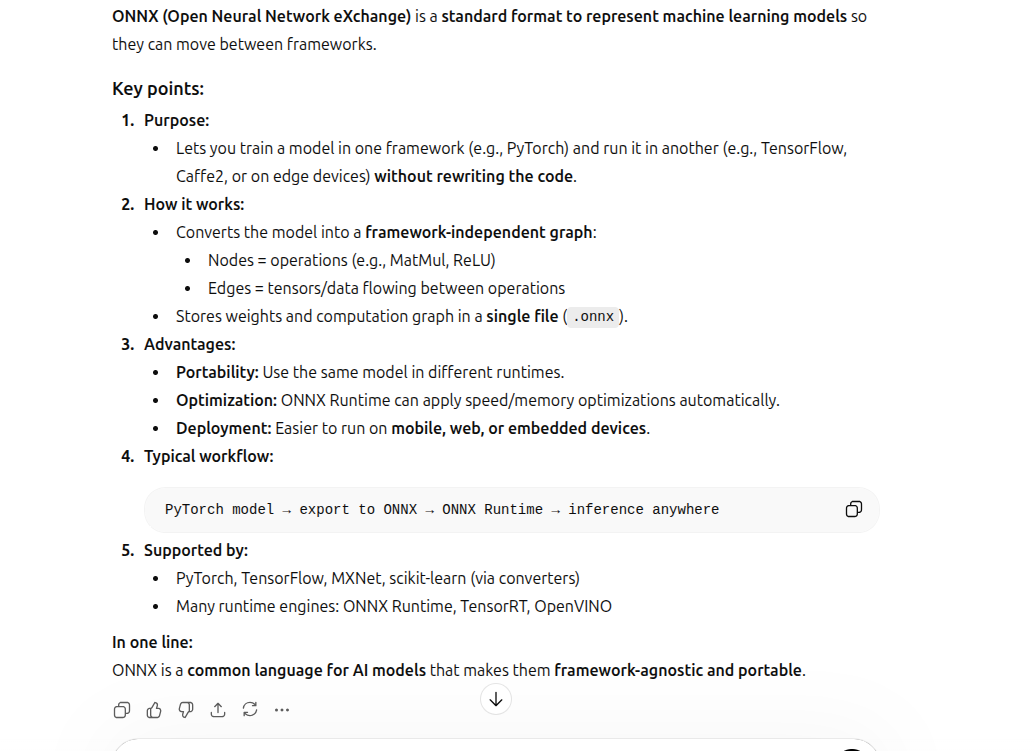

ONNX (Open Neural Network Exchange)[25] was an early effort to create a unified format for
deploying models across various frameworks and platforms.

## llama.cpp

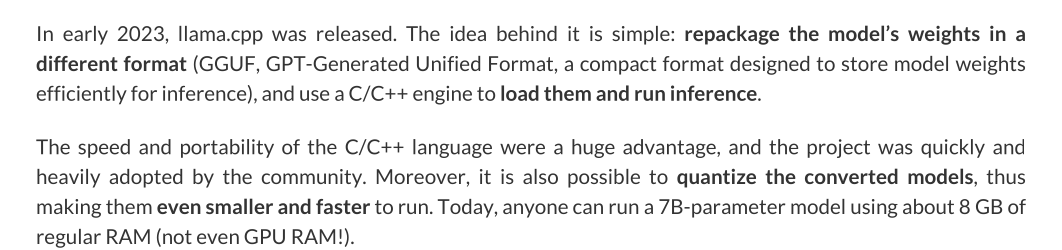

While the base models are easily available in the GGUF format, and at different levels of quantization, serving
our own fine-tuned models requires a bit of extra work. Deploying them locally requires converting and
quantizing models and adapters ourselves.

Once converted, these models can be served—that is, made available—either through a web interface or a
REST API using llama.cpp itself or Ollama, one of the most popular tools for using LLMs locally.|

## Loading Models and Adapters

In [ ]:
import torch
from peft import PeftModel, PeftConfig, AutoPeftModelForCausalLM, get_model_status, get_layer_status
from transformers import AutoModelForCausalLM, AutoTokenizer
 

## — read adapter config

PeftConfig tells us which base model was used during training

This is the safest way to find the base model name — don't hard-code it.


In [13]:
pwd

'/home/ujjwal/newprojeects/Fine-Tuning-LLM/depoly'

In [12]:

repo_or_folder = "yoda-adapter"  

In [16]:
repo_or_folder = '../yoda-adapter'  # go up one level
config = PeftConfig.from_pretrained(repo_or_folder, local_files_only=True)

config

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path='facebook/opt-350m', revision=None, inference_mode=True, r=16, target_modules={'v_proj', 'q_proj', 'k_proj', 'project_out', 'project_in', 'fc1', 'fc2', 'out_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['lm_head', 'embed_tokens'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)

above is the  the LoRA configuration used to fine-tune the adapter. The base model is listed in the
base_model_name_or_path argument, so let’s use this to load the model:

In [17]:
print(config.base_model_name_or_path)


facebook/opt-350m


## load the base model

In [19]:
base_model = AutoModelForCausalLM.from_pretrained(config.base_model_name_or_path, device_map='auto')



Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

## to load model = base_model + yoda_adapter 

### note that adapter has differente size of embedding because we add some special tokenes 

### so when we  load it, the shapes must match

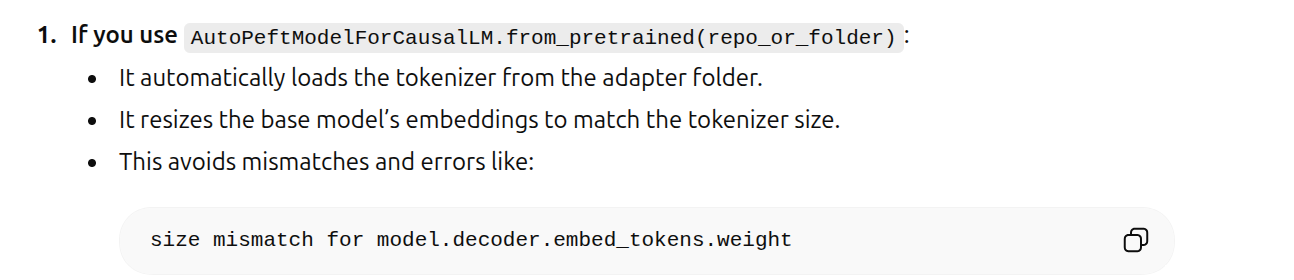

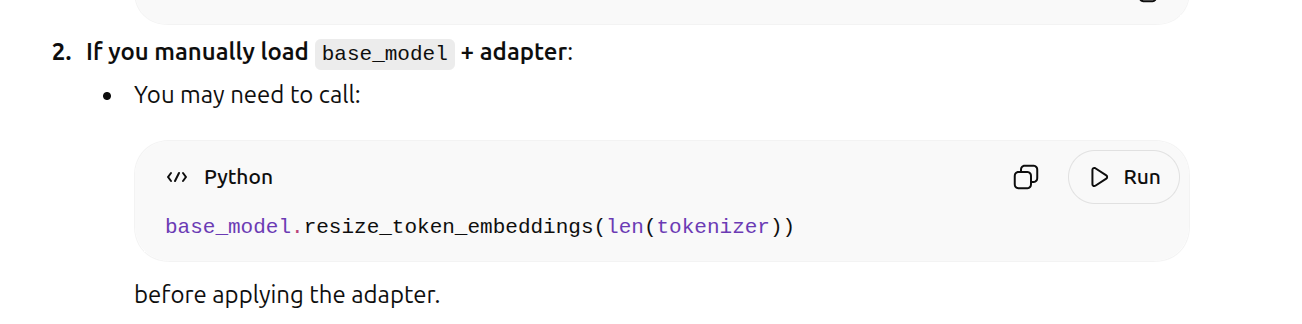

In [20]:
model = PeftModel.from_pretrained(base_model, repo_or_folder, adapter_name='lora3')

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


### it works how?? 

When you call modify_tokenizer() + modify_model() during training, two things happen:

tokenizer = modify_tokenizer(tokenizer)   # adds <|im_start|>, <unk> → vocab grows


model = modify_model(model, tokenizer)    # calls resize_token_embeddings() → embeds grow

So the saved adapter in yoda-adapter/ contains:

adapter_model.safetensors — the LoRA weights plus the full lm_head and embed_tokens matrices at the new size (because of modules_to_save=["lm_head", "embed_tokens"])


tokenizer.json — with the new tokens baked in



## why does PeftModel.from_pretrained() work without manual resize?


#####  because it never merger , It keeps the base and the LoRA layers separate, like [base_model, lora_adapter]. The adapter lives alongside the base, and generation #### routes through it automatically. 

#### Only merge_and_unload() actually combines them, which is when resizing matters.”

# even they are not true merger , can i get output of model + lora  - yes

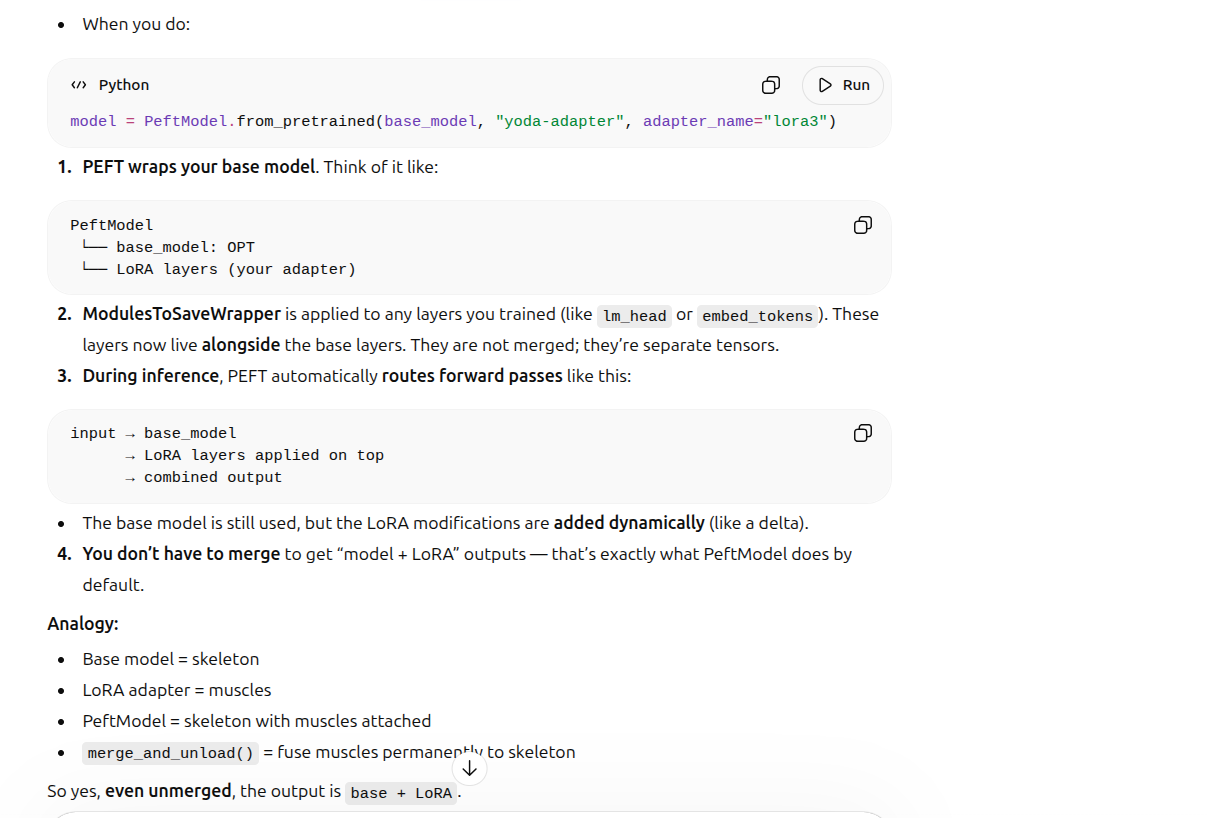

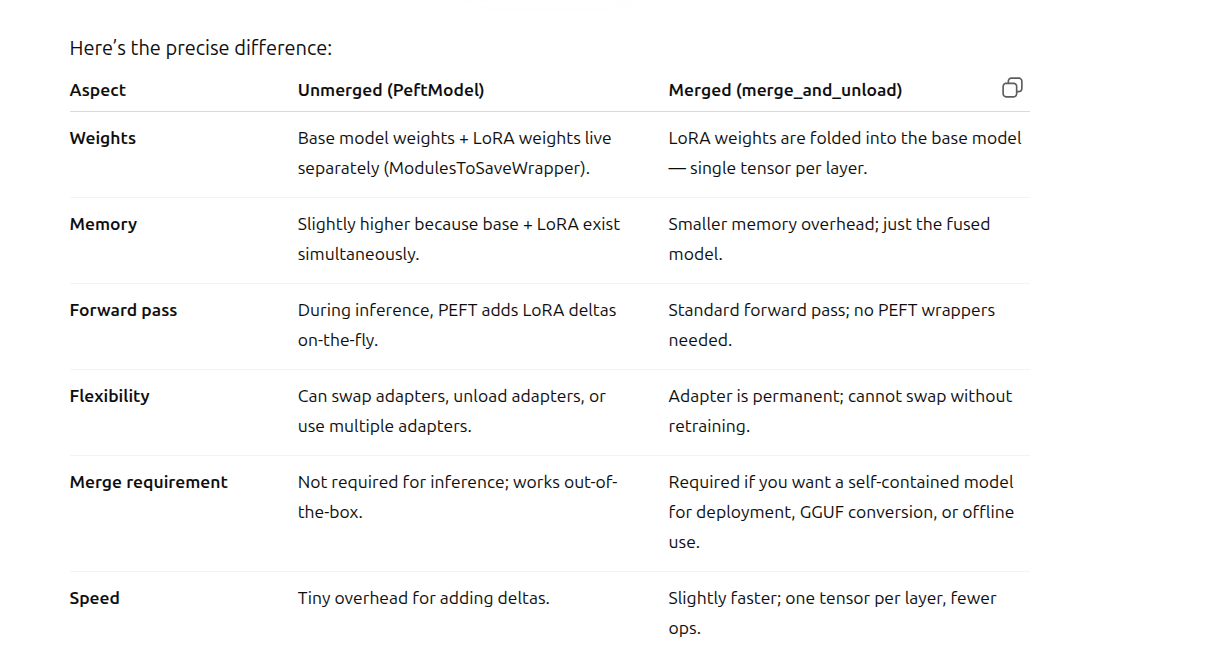

In [28]:
model = PeftModel.from_pretrained(base_model, repo_or_folder, adapter_name='yoda')
model

/home/ujjwal/projects/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): OPTForCausalLM(
      (model): OPTModel(
        (decoder): OPTDecoder(
          (embed_tokens): ModulesToSaveWrapper(
            (original_module): Embedding(50272, 512, padding_idx=1)
            (modules_to_save): ModuleDict(
              (lora3): Embedding(50272, 512, padding_idx=1)
              (yoda): Embedding(50272, 512, padding_idx=1)
            )
          )
          (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
          (project_out): lora.Linear(
            (base_layer): Linear(in_features=1024, out_features=512, bias=False)
            (lora_dropout): ModuleDict(
              (lora3): Dropout(p=0.05, inplace=False)
              (yoda): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (lora3): Linear(in_features=1024, out_features=16, bias=False)
              (yoda): Linear(in_features=1024, out_features=16, bias=False)
            )
          

## merge the adapters:

must load the tokenizer

In [30]:
tokenizer = AutoTokenizer.from_pretrained(repo_or_folder)

Tokenizer defines IDs for tokens  : 

Every token (word/subword/special token) maps to an integer ID.

Your model’s embedding layer is tied to these IDs — it expects certain positions to correspond to certain tokens.

## change the vocab or special tokens

Example: you added <|im_start|> or <unk> during training.

During training, these new tokens had specific IDs assigned by the tokenizer.

The LoRA adapter’s lm_head and embed_tokens were trained with those IDs in mind.

## Loading the base tokenizer (without the new tokens)

Base tokenizer can still encode/decode text — no error occurs.

But the new special tokens are missing → they get mapped to [UNK] or some other ID.

The model now receives token IDs it was never trained on.

##  Resulting silent failure

Model can run inference without crashing.

Output may be garbled or misaligned because embeddings for the missing or shifted IDs are wrong.

Especially bad in chat templates: prompts like "assistant\n" might get tokenized differently, so the model doesn’t know whose turn it is.

# Rule of thumb:

if we  modified tokens or vocab. Always load the tokenizer from the adapter folder, not from the base model,

This ensures token IDs match the ones the LoRA adapter was trained with.

##  AutoPeftModelForCausalLM

under the hood, it checks for the tokenizer saved in the adapter folder or repository and, when it finds
one, it uses its length to automatically resize the embedding layer:

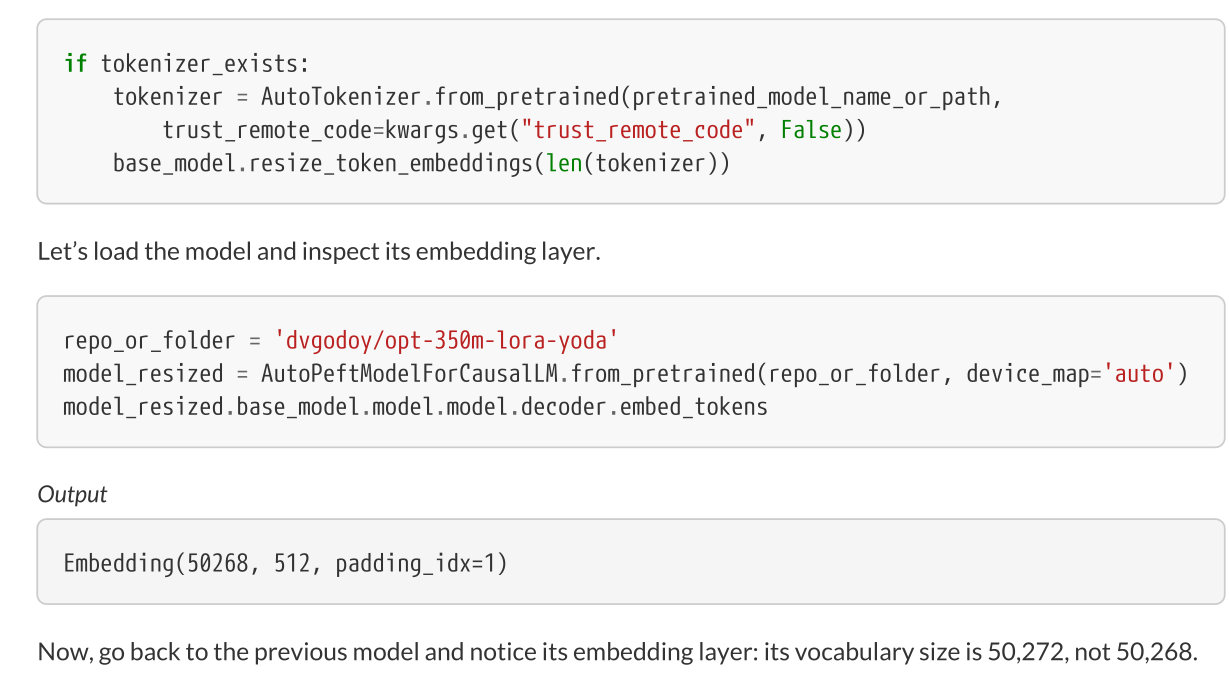

## to be continued